In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kalilurrahman_tcs_stock_data_live_and_latest_path = kagglehub.dataset_download('kalilurrahman/tcs-stock-data-live-and-latest')

print('Data source import complete.')


100%|██████████| 177k/177k [00:00<00:00, 64.1MB/s]

Extracting files...
Data source import complete.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tqdm import tqdm



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# ****Loading Data

In [4]:
df=pd.read_csv('/content/TCS_stock_action.csv')
df.head()

,Date,Dividends,Stock Splits
0,2004-10-28,0.3750,0.0
1,2005-02-03,0.4375,0.0
2,2005-07-06,0.6250,0.0
3,2005-08-18,0.3750,0.0
4,2005-10-18,0.3750,0.0


In [5]:
df.columns

Index(['Date', 'Dividends', 'Stock Splits'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          70 non-null     object 
 1   Dividends     70 non-null     float64
 2   Stock Splits  70 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.8+ KB


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

In [8]:
df.describe()

,Date,Dividends,Stock Splits
count,70,70.000000,70.000000
mean,2013-05-10 13:42:51.428571392,4.560714,0.085714
min,2004-10-28 00:00:00,0.375000,0.000000
25%,2009-03-03 18:00:00,1.000000,0.000000
50%,2013-07-02 12:00:00,2.500000,0.000000
75%,2017-07-13 18:00:00,5.000000,0.000000
max,2021-07-15 00:00:00,40.000000,2.000000
std,NaN,6.284794,0.407995


# ****Correlation Of Features

In [9]:
corel=df.corr()
corel

,Date,Dividends,Stock Splits
Date,1.000000,0.558649,-0.080974
Dividends,0.558649,1.000000,0.027614
Stock Splits,-0.080974,0.027614,1.000000


In [13]:
# Correlation of features with the target variable (Close Price)
correlation_with_close = df.corr()['Stock Splits'].sort_values(ascending=False)
print(correlation_with_close)


Stock Splits    1.000000
Dividends       0.027614
Date           -0.080974
Name: Stock Splits, dtype: float64


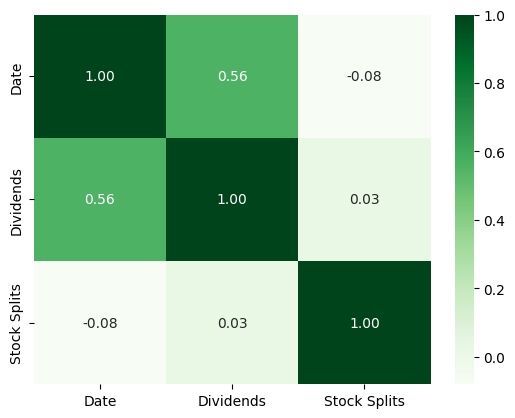

In [11]:
sns.heatmap(corel,annot= True,cmap= "Greens",fmt=".2f")
plt.show()

# ****Exploratory Data Analysis

# Time series of stock prices


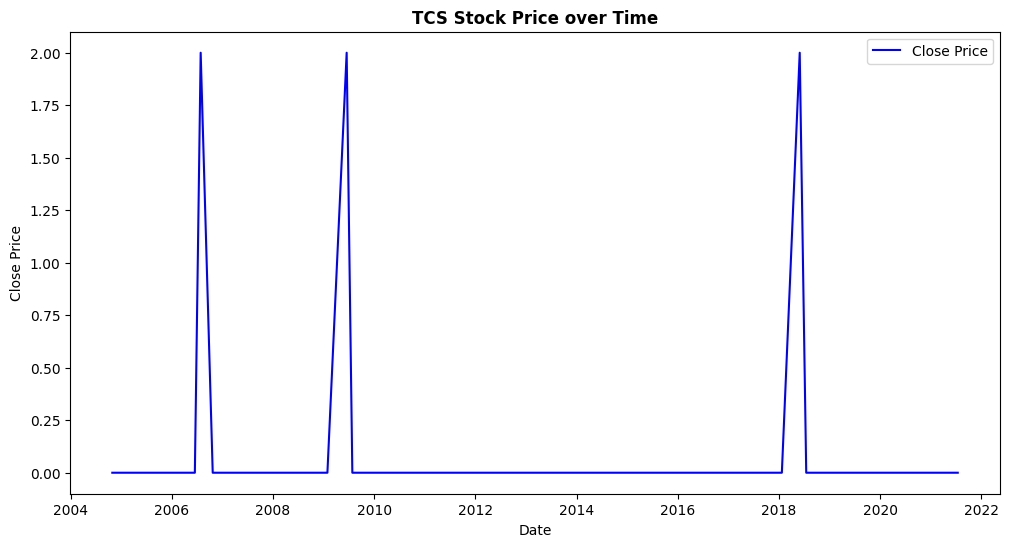

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Stock Splits'], label='Close Price', color='b')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('TCS Stock Price over Time',weight = "bold")
plt.legend()
plt.show()

# Volume, Dividends, Stock Splits

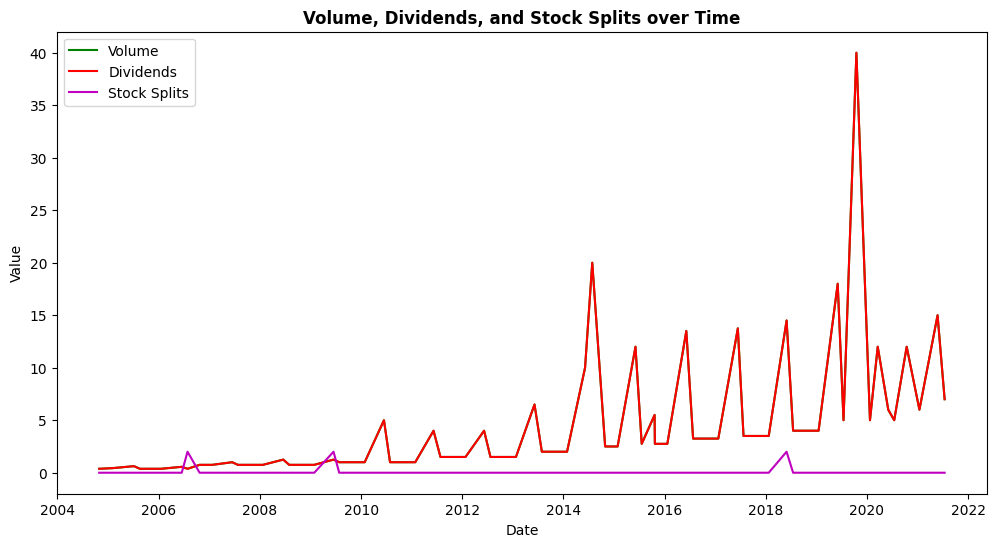

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Dividends'], label='Volume', color='g')
plt.plot(df['Date'], df['Dividends'], label='Dividends', color='r')
plt.plot(df['Date'], df['Stock Splits'], label='Stock Splits', color='m')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Volume, Dividends, and Stock Splits over Time',weight = "bold")
plt.legend()
plt.show()

# Close vs Volume

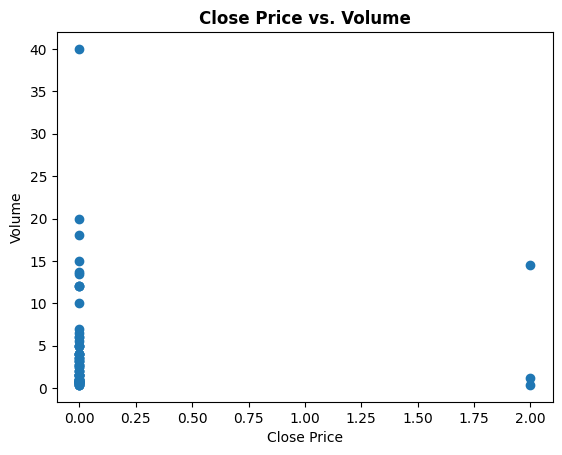

In [22]:
plt.scatter(df['Stock Splits'], df['Dividends'])
plt.xlabel('Close Price')
plt.ylabel('Volume')
plt.title('Close Price vs. Volume',weight= "bold")
plt.show()


# Dividends and Stock Splits

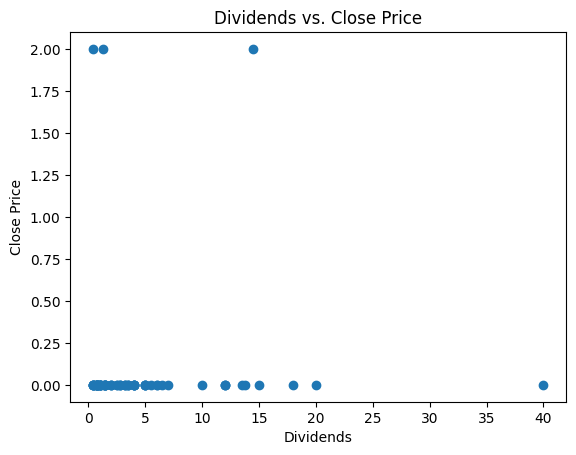

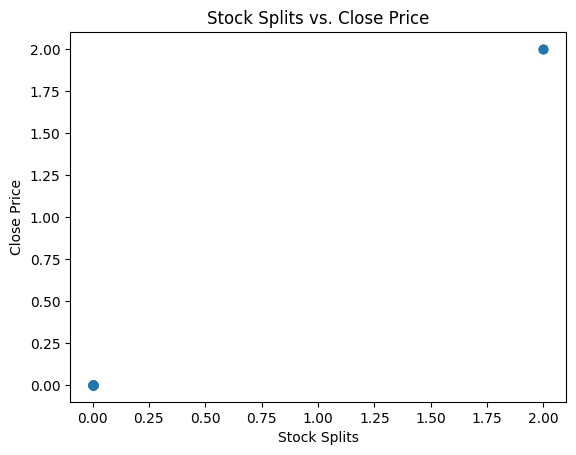

In [25]:
# Dividends vs. Close Price
plt.scatter(df['Dividends'], df['Stock Splits'])
plt.xlabel('Dividends')
plt.ylabel('Close Price')
plt.title('Dividends vs. Close Price')
plt.show()

# Stock Splits vs. Close Price
plt.scatter(df['Stock Splits'], df['Stock Splits'])
plt.xlabel('Stock Splits')
plt.ylabel('Close Price')
plt.title('Stock Splits vs. Close Price')
plt.show()


# Moving Averages

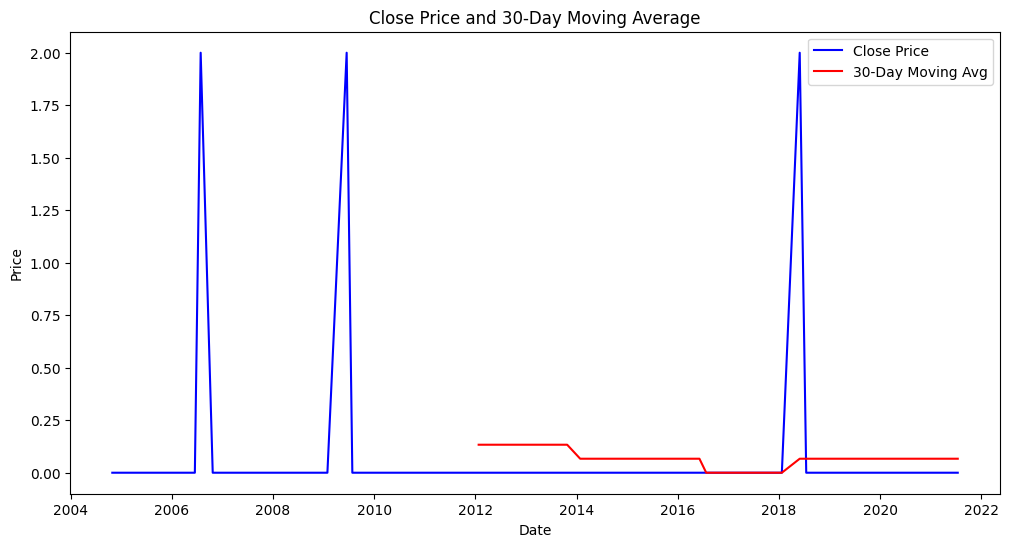

In [28]:
df['30-Day Moving Avg'] = df['Stock Splits'].rolling(window=30).mean()

# Plot Close price and moving average
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Stock Splits'], label='Close Price', color='b')
plt.plot(df['Date'], df['30-Day Moving Avg'], label='30-Day Moving Avg', color='r')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Close Price and 30-Day Moving Average')
plt.legend()
plt.show()


# Moving Average Crossover Strategy

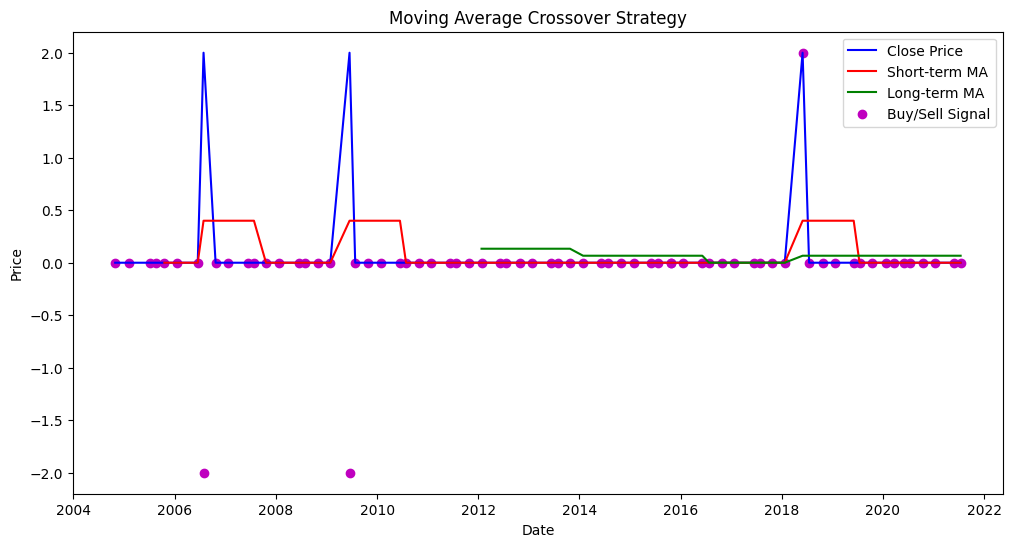

In [32]:
df['Short_MA'] = df['Stock Splits'].rolling(window=5).mean()
df['Long_MA'] = df['Stock Splits'].rolling(window=30).mean()

# Creating a trading signals based on moving average crossovers
df['Signal'] = np.where(df['Short_MA'] > df['Long_MA'], 1, -1)

# Plot the strategy signals
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Stock Splits'], label='Close Price', color='b')
plt.plot(df['Date'], df['Short_MA'], label='Short-term MA', color='r')
plt.plot(df['Date'], df['Long_MA'], label='Long-term MA', color='g')
plt.scatter(df['Date'], df['Stock Splits'] * df['Signal'], label='Buy/Sell Signal', marker='o', color='m')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Moving Average Crossover Strategy')
plt.legend()
plt.show()


# Daily Price Change

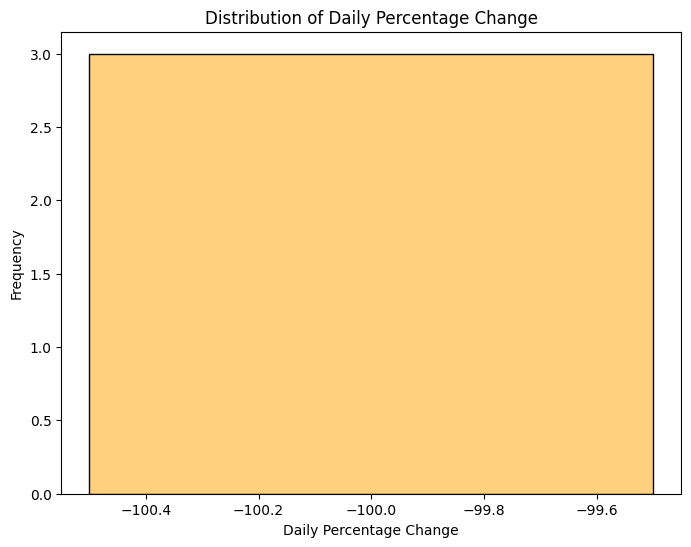

In [34]:
df['Daily_Price_Change'] = df['Stock Splits'].pct_change() * 100

# Distribution of daily percentage change
plt.figure(figsize=(8, 6))
sns.histplot(df['Daily_Price_Change'].dropna(), kde=True, color='orange')
plt.xlabel('Daily Percentage Change')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Percentage Change')
plt.show()


# ****Feature Engineering

In [36]:
df['Moving_Avg_Close'] = df['Stock Splits'].rolling(window=7).mean()

# ****Modelling

In [37]:
df.shape

(70, 9)

# Data Preparation & Normalization

In [41]:
# Prepare the data for LSTM
X_train = df['Stock Splits'].values.reshape(-1, 1)
y_train = df['Stock Splits'].shift(-1).dropna().values

# Normalize the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Define the test data
test_ratio = 0.2
test_size = int(len(df) * test_ratio)
test_data = df[-test_size:]

# Prepare the data for prediction
X_test = test_data['Stock Splits'].values.reshape(-1, 1)
X_test_scaled = scaler.transform(X_test)
X_test_lstm = X_test_scaled.reshape(-1, 1, 1)


# Reshaping Data

In [42]:
# Reshape the data for LSTM
X_train_lstm = X_train_scaled[:-1].reshape(-1, 1, 1)
y_train_lstm = X_train_scaled[1:]

# Building a LSTM Model

In [44]:
model = Sequential()
model.add(LSTM(50, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Set the number of epochs and batch size
epochs = 30
batch_size = 15

# Train the model with tqdm progress bar
for epoch in tqdm(range(epochs)):
    for i in range(0, len(X_train_lstm), batch_size):
        X_batch = X_train_lstm[i:i+batch_size]
        y_batch = y_train_lstm[i:i+batch_size]
        model.train_on_batch(X_batch, y_batch)

# Prepare the data for prediction
X_test = test_data['Stock Splits'].values.reshape(-1, 1)
X_test_scaled = scaler.transform(X_test)
X_test_lstm = X_test_scaled.reshape(-1, 1, 1)

100%|██████████| 30/30 [00:02<00:00, 13.31it/s]


# Predictions using LSTM

In [45]:
lstm_predictions = model.predict(X_test_lstm).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


# Inverse transform of the predictions

In [46]:
lstm_predictions = lstm_predictions.reshape(-1, 1)
lstm_predictions = scaler.inverse_transform(lstm_predictions)


# Visualization of LSTM predictions

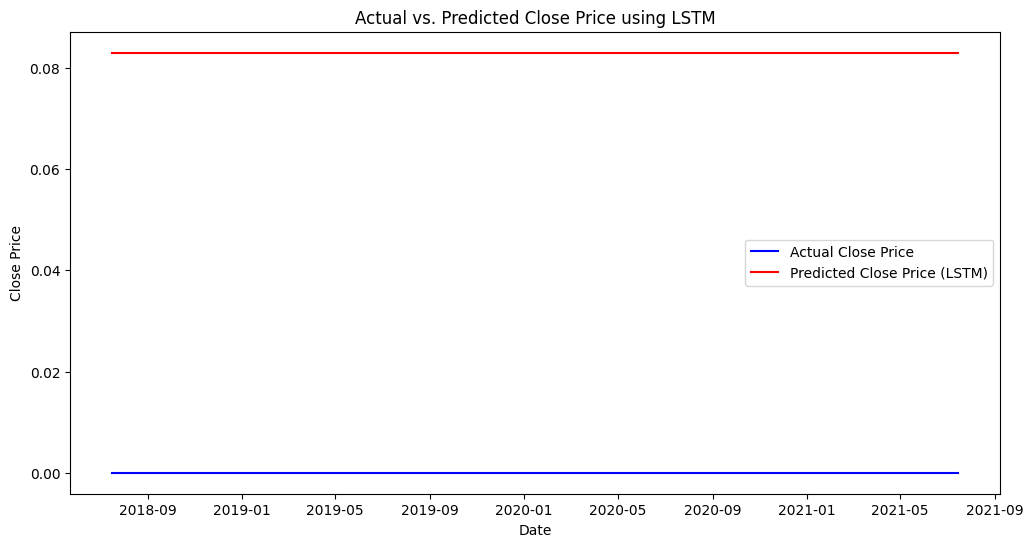

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'], test_data['Stock Splits'], label='Actual Close Price', color='b')
plt.plot(test_data['Date'], lstm_predictions, label='Predicted Close Price (LSTM)', color='r')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Actual vs. Predicted Close Price using LSTM')
plt.legend()
plt.show()

# Mean Absolute Error

In [50]:
lstm_mae = mean_absolute_error(test_data['Stock Splits'], lstm_predictions)
print("LSTM Mean Absolute Error:", lstm_mae)

LSTM Mean Absolute Error: 0.08301256597042084


In [51]:
lstm_predictions = lstm_predictions.reshape(-1, 1)
lstm_predictions = scaler.inverse_transform(lstm_predictions)


date_index = test_data.index[-len(lstm_predictions):]
predictions_df = pd.DataFrame({'Date': date_index, 'Predicted_Close': lstm_predictions.flatten()})


predictions_df.to_csv('predictions.csv', index=False)
